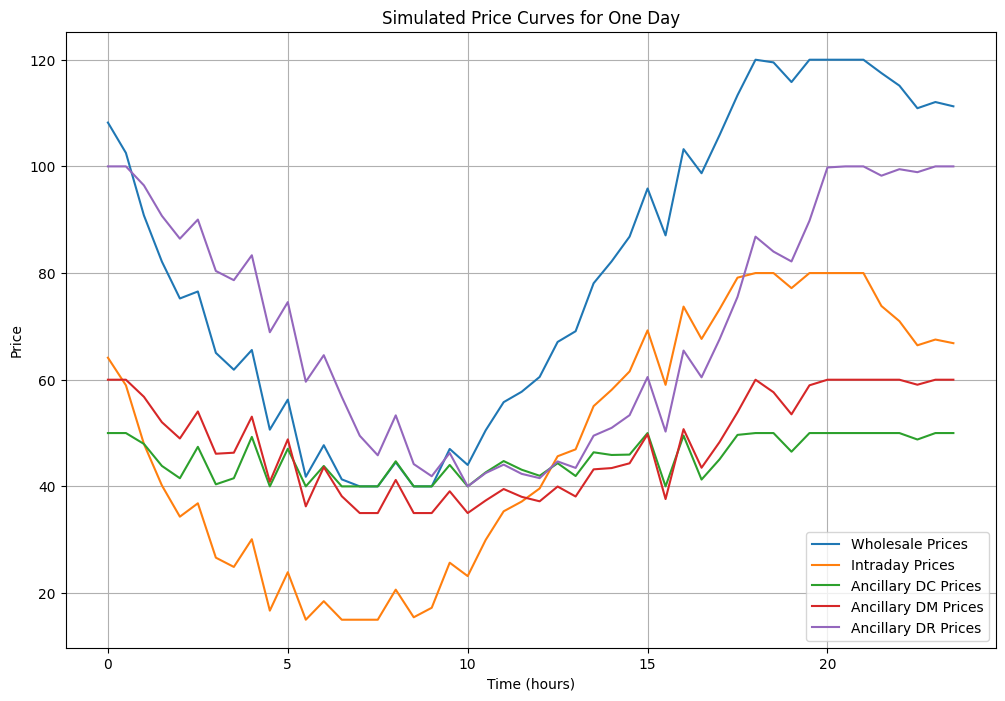

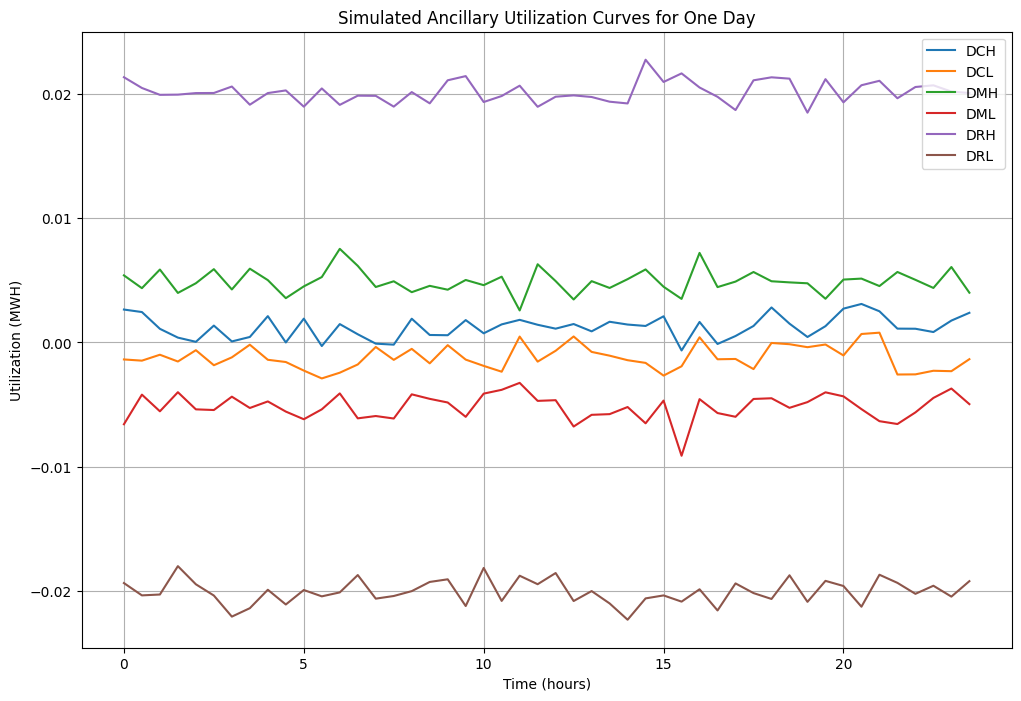

In [1]:
import numpy as np
import datetime
import matplotlib.pyplot as plt

def generate_price_curve(peak_price, lowest_price, peak_time, num_samples=48, noise_level=5, base_datetime=None):
    """
    Generate a price curve with specified peak and lowest prices, peak time, and random noise.
    
    :param peak_price: The highest price during peak time.
    :param lowest_price: The lowest price during offpeak time.
    :param peak_time: The time (in hours) when the peak price occurs.
    :param num_samples: Number of samples to generate (default is 48 for 30-minute intervals).
    :param noise_level: The level of random noise to add to the prices.
    :param base_datetime: The base datetime to generate the curve from.
    :return: A tuple of time points and prices.
    """
    if base_datetime is None:
        base_datetime = datetime.datetime.now()
    
    # Generate time points
    time_points = np.arange(0, 24, 24/num_samples)
    
    # Generate a sinusoidal curve to simulate the price variation
    prices = (peak_price - lowest_price) / 2 * np.sin(2 * np.pi * (time_points - peak_time) / 24) + (peak_price + lowest_price) / 2
    
    # Add random noise
    np.random.seed(int(base_datetime.timestamp()))  # Seed the random generator with the base datetime
    noise = np.random.normal(0, noise_level, num_samples)
    prices += noise
    
    # Adjust prices to ensure they stay within the specified range
    prices = np.clip(prices, lowest_price, peak_price)
    
    return time_points, prices

def generate_price_curves(base_datetime, num_samples):
    """
    Generate price curves for Wholesale, Intraday, and Ancillary markets.
    
    :param base_datetime: The base datetime to generate the curves from.
    :param num_samples: Number of samples to generate.
    :return: Price curves for Wholesale, Intraday, and Ancillary markets.
    """
    # Parameters for price curves
    wholesale_peak_price = 120
    wholesale_lowest_price = 40
    wholesale_peak_time = 14  # 2 PM
    
    intraday_peak_price = 80
    intraday_lowest_price = 15
    intraday_peak_time = 13  # 1 PM
    
    ancillary_dc_peak_price = 50
    ancillary_dc_lowest_price = 40
    ancillary_dc_peak_time = 15  # 3 PM
    
    ancillary_dm_peak_price = 60
    ancillary_dm_lowest_price = 35
    ancillary_dm_peak_time = 16  # 4 PM
    
    ancillary_dr_peak_price = 100
    ancillary_dr_lowest_price = 40
    ancillary_dr_peak_time = 17  # 5 PM
    
    # Generate price curves
    wholesale_time, wholesale_prices = generate_price_curve(wholesale_peak_price, wholesale_lowest_price, wholesale_peak_time, num_samples, noise_level=5, base_datetime=base_datetime)
    intraday_time, intraday_prices = generate_price_curve(intraday_peak_price, intraday_lowest_price, intraday_peak_time, num_samples, noise_level=5, base_datetime=base_datetime)
    ancillary_dc_time, ancillary_dc_prices = generate_price_curve(ancillary_dc_peak_price, ancillary_dc_lowest_price, ancillary_dc_peak_time, num_samples, noise_level=5, base_datetime=base_datetime)
    ancillary_dm_time, ancillary_dm_prices = generate_price_curve(ancillary_dm_peak_price, ancillary_dm_lowest_price, ancillary_dm_peak_time, num_samples, noise_level=5, base_datetime=base_datetime)
    ancillary_dr_time, ancillary_dr_prices = generate_price_curve(ancillary_dr_peak_price, ancillary_dr_lowest_price, ancillary_dr_peak_time, num_samples, noise_level=5, base_datetime=base_datetime)
    
    return (wholesale_time, wholesale_prices), (intraday_time, intraday_prices), (ancillary_dc_time, ancillary_dc_prices), (ancillary_dm_time, ancillary_dm_prices), (ancillary_dr_time, ancillary_dr_prices)

def generate_utilization_curve(base_datetime, num_samples):
    """
    Generate utilization curves for the Ancillary market.
    
    :param base_datetime: The base datetime to generate the curve from.
    :param num_samples: Number of samples to generate.
    :return: Utilization curve for the Ancillary market.
    """
    # Parameters for utilization curves
    means = {
        'DCH': 0.001,
        'DCL': -0.001,
        'DMH': 0.005,
        'DML': -0.005,
        'DRH': 0.02,
        'DRL': -0.02
    }
    noise_level = 0.001  # Adjust the noise level as needed
    
    # Initialize utilization curves
    utilization_curves = {service: [] for service in means.keys()}
    
    # Generate utilization curves with noise
    np.random.seed(int(base_datetime.timestamp()))  # Seed the random generator with the base datetime
    for service, mean in means.items():
        utilization = mean + np.random.normal(0, noise_level, num_samples)
        utilization_curves[service] = utilization
    
    return utilization_curves

# Example usage
base_datetime = datetime.datetime(2025, 2, 24, 0, 0)
num_days = 1
num_samples_per_day = 48  # 48 samples per day (30-minute intervals)

# Initialize lists to store the results
all_wholesale_prices = []
all_intraday_prices = []
all_ancillary_dc_prices = []
all_ancillary_dm_prices = []
all_ancillary_dr_prices = []
all_ancillary_utilization = {service: [] for service in ['DCH', 'DCL', 'DMH', 'DML', 'DRH', 'DRL']}

# Generate price and utilization curves for each day
for day in range(num_days):
    current_datetime = base_datetime + datetime.timedelta(days=day)
    (wholesale_time, wholesale_prices), (intraday_time, intraday_prices), (ancillary_dc_time, ancillary_dc_prices), (ancillary_dm_time, ancillary_dm_prices), (ancillary_dr_time, ancillary_dr_prices) = generate_price_curves(current_datetime, num_samples_per_day)
    ancillary_utilization = generate_utilization_curve(current_datetime, num_samples_per_day)
    
    all_wholesale_prices.append((wholesale_time + day * 24, wholesale_prices))
    all_intraday_prices.append((intraday_time + day * 24, intraday_prices))
    all_ancillary_dc_prices.append((ancillary_dc_time + day * 24, ancillary_dc_prices))
    all_ancillary_dm_prices.append((ancillary_dm_time + day * 24, ancillary_dm_prices))
    all_ancillary_dr_prices.append((ancillary_dr_time + day * 24, ancillary_dr_prices))
    for service in all_ancillary_utilization.keys():
        all_ancillary_utilization[service].append((ancillary_dc_time + day * 24, ancillary_utilization[service]))

# Flatten the lists
all_wholesale_time_index = np.concatenate([t for t, _ in all_wholesale_prices])
all_wholesale_price_values = np.concatenate([v for _, v in all_wholesale_prices])
all_intraday_time_index = np.concatenate([t for t, _ in all_intraday_prices])
all_intraday_price_values = np.concatenate([v for _, v in all_intraday_prices])
all_ancillary_dc_time_index = np.concatenate([t for t, _ in all_ancillary_dc_prices])
all_ancillary_dc_price_values = np.concatenate([v for _, v in all_ancillary_dc_prices])
all_ancillary_dm_time_index = np.concatenate([t for t, _ in all_ancillary_dm_prices])
all_ancillary_dm_price_values = np.concatenate([v for _, v in all_ancillary_dm_prices])
all_ancillary_dr_time_index = np.concatenate([t for t, _ in all_ancillary_dr_prices])
all_ancillary_dr_price_values = np.concatenate([v for _, v in all_ancillary_dr_prices])

# Plot the price curves
plt.figure(figsize=(12, 8))
plt.plot(all_wholesale_time_index, all_wholesale_price_values, label='Wholesale Prices', color='tab:blue')
plt.plot(all_intraday_time_index, all_intraday_price_values, label='Intraday Prices', color='tab:orange')
plt.plot(all_ancillary_dc_time_index, all_ancillary_dc_price_values, label='Ancillary DC Prices', color='tab:green')
plt.plot(all_ancillary_dm_time_index, all_ancillary_dm_price_values, label='Ancillary DM Prices', color='tab:red')
plt.plot(all_ancillary_dr_time_index, all_ancillary_dr_price_values, label='Ancillary DR Prices', color='tab:purple')
plt.xlabel('Time (hours)')
plt.ylabel('Price')
plt.title('Simulated Price Curves for One Day')
plt.legend()
plt.grid(True)
plt.show()

# Plot the utilization curves
plt.figure(figsize=(12, 8))
for service, utilizations in all_ancillary_utilization.items():
    all_time_index = np.concatenate([t for t, _ in utilizations])
    all_price_values = np.concatenate([v for _, v in utilizations])
    plt.plot(all_time_index, all_price_values, label=service)

plt.xlabel('Time (hours)')
plt.ylabel('Utilization (MWH)')
plt.title('Simulated Ancillary Utilization Curves for One Day')
plt.legend()
plt.grid(True)
plt.show()


In [2]:

import pyomo.environ as pyo

# Define constants
eta_ch = 0.95  # Charging efficiency
eta_dis = 0.95  # Discharging efficiency
interval = 0.5  # Time interval in hours (30 minutes)
C = 100  # Battery capacity in MWh
P_max = 100  # Maximum power in MW
initial_soc = 0.3  # Initial state of charge
final_soc = 0.3  # Final state of charge
SOC_H = 0.95 # Upper SOC limit
SOC_L = 0.05  # Lower SOC limit

# Define the Pyomo model
model = pyo.ConcreteModel()

# Define the time index
num_days = 1
num_samples_per_day = 48
model.t = pyo.RangeSet(0, num_days * num_samples_per_day - 1)

# Define decision variables for each type of market and ancillary service
model.wholesale_charge = pyo.Var(model.t, within=pyo.NonNegativeReals,bounds=(0, P_max))
model.intraday_charge = pyo.Var(model.t, within=pyo.NonNegativeReals,bounds=(0, P_max))
model.ancillary_dc_high_charge = pyo.Var(model.t, within=pyo.NonNegativeReals,bounds=(0, P_max))
model.ancillary_dm_high_charge = pyo.Var(model.t, within=pyo.NonNegativeReals,bounds=(0, P_max))
model.ancillary_dr_high_charge = pyo.Var(model.t, within=pyo.NonNegativeReals,bounds=(0, P_max))

model.wholesale_discharge = pyo.Var(model.t, within=pyo.NonNegativeReals,bounds=(0, P_max))
model.intraday_discharge = pyo.Var(model.t, within=pyo.NonNegativeReals,bounds=(0, P_max))
model.ancillary_dc_low_discharge = pyo.Var(model.t, within=pyo.NonNegativeReals,bounds=(0, P_max))
model.ancillary_dm_low_discharge = pyo.Var(model.t, within=pyo.NonNegativeReals,bounds=(0, P_max))
model.ancillary_dr_low_discharge = pyo.Var(model.t, within=pyo.NonNegativeReals,bounds=(0, P_max))

# Define the state of charge (SoC) variable
model.soc = pyo.Var(model.t, within=pyo.NonNegativeReals, bounds=(SOC_L, SOC_H))
model.initial_soc_constraint = pyo.Constraint(expr=model.soc[0] == initial_soc, doc="Initial SOC")
model.final_soc_constraint = pyo.Constraint(expr=model.soc[num_days * num_samples_per_day - 1] == final_soc, doc="Final SOC")

def soc_constraint(model, t):
    if t == 0:
        return pyo.Constraint.Skip  # Initial SoC is handled by initial_soc_constraint
    P_charging = (model.wholesale_charge[t] + model.intraday_charge[t] + 
                  all_ancillary_utilization['DCH'][0][1][t] * model.ancillary_dc_high_charge[t] + 
                  all_ancillary_utilization['DMH'][0][1][t] * model.ancillary_dm_high_charge[t] + 
                  all_ancillary_utilization['DRH'][0][1][t] * model.ancillary_dr_high_charge[t])
    P_discharging = (model.wholesale_discharge[t] + model.intraday_discharge[t] + 
                     all_ancillary_utilization['DCL'][0][1][t] * model.ancillary_dc_low_discharge[t] + 
                     all_ancillary_utilization['DML'][0][1][t] * model.ancillary_dm_low_discharge[t] + 
                     all_ancillary_utilization['DRL'][0][1][t] * model.ancillary_dr_low_discharge[t])
    return model.soc[t] == model.soc[t-1] + (eta_ch * P_charging * interval / C) - (P_discharging * interval / (eta_dis * C))
model.soc_constraint = pyo.Constraint(model.t, rule=soc_constraint)

# Define the wholesale booking constraint
def wholesale_charging_booking_constraint(model, t):
    if t % 2 == 0 and t < num_days * num_samples_per_day - 1:
        return model.wholesale_charge[t] == model.wholesale_charge[t+1]
    return pyo.Constraint.Skip
model.wholesale_charging_booking_constraint = pyo.Constraint(model.t, rule=wholesale_charging_booking_constraint)

def wholesale_discharge_booking_constraint(model, t):
    if t % 2 == 0 and t < num_days * num_samples_per_day - 1:
        return model.wholesale_discharge[t] == model.wholesale_discharge[t+1]
    return pyo.Constraint.Skip
model.wholesale_discharge_booking_constraint = pyo.Constraint(model.t, rule=wholesale_discharge_booking_constraint)

# Define the constraint for wholesale charge and discharge
def wholesale_total_constraint(model, t):
    return model.wholesale_charge[t] + model.wholesale_discharge[t] <= P_max
model.wholesale_total_constraint = pyo.Constraint(model.t, rule=wholesale_total_constraint)

# Define the constraint for intraday charge and discharge
def intraday_total_constraint(model, t):
    return model.intraday_charge[t] + model.intraday_discharge[t] <= P_max
model.intraday_total_constraint = pyo.Constraint(model.t, rule=intraday_total_constraint)

# dc_high
def create_ancillary_dc_high_booking_constraint(model, t, offset):
    if t % 8 == 0 and t < num_days * num_samples_per_day - 7:
        return model.ancillary_dc_high_charge[t] == model.ancillary_dc_high_charge[t + offset]
    return pyo.Constraint.Skip

for i in range(8):
    setattr(model, f'ancillary_dc_high_booking_constraint_{i}', pyo.Constraint(model.t, rule=lambda model, t, i=i: create_ancillary_dc_high_booking_constraint(model, t, i)))

# dc_low
def create_ancillary_dc_low_booking_constraint(model, t, offset):
    if t % 8 == 0 and t < num_days * num_samples_per_day - 7:
        return model.ancillary_dc_low_discharge[t] == model.ancillary_dc_low_discharge[t + offset]
    return pyo.Constraint.Skip

for i in range(8):
    setattr(model, f'ancillary_dc_low_booking_constraint_{i}', pyo.Constraint(model.t, rule=lambda model, t, i=i: create_ancillary_dc_low_booking_constraint(model, t, i)))

# dm_high
def create_ancillary_dm_high_booking_constraint(model, t, offset):
    if t % 8 == 0 and t < num_days * num_samples_per_day - 7:
        return model.ancillary_dm_high_charge[t] == model.ancillary_dm_high_charge[t + offset]
    return pyo.Constraint.Skip

for i in range(8):
    setattr(model, f'ancillary_dm_high_booking_constraint_{i}', pyo.Constraint(model.t, rule=lambda model, t, i=i: create_ancillary_dm_high_booking_constraint(model, t, i)))

#dm_low
def create_ancillary_dm_low_booking_constraint(model, t, offset):
    if t % 8 == 0 and t < num_days * num_samples_per_day - 7:
        return model.ancillary_dm_low_discharge[t] == model.ancillary_dm_low_discharge[t + offset]
    return pyo.Constraint.Skip

for i in range(8):
    setattr(model, f'ancillary_dm_low_booking_constraint_{i}', pyo.Constraint(model.t, rule=lambda model, t, i=i: create_ancillary_dm_low_booking_constraint(model, t, i)))

# dr_high
def create_ancillary_dr_high_booking_constraint(model, t, offset):
    if t % 8 == 0 and t < num_days * num_samples_per_day - 7:
        return model.ancillary_dr_high_charge[t] == model.ancillary_dr_high_charge[t + offset]
    return pyo.Constraint.Skip

for i in range(8):
    setattr(model, f'ancillary_dr_high_booking_constraint_{i}', pyo.Constraint(model.t, rule=lambda model, t, i=i: create_ancillary_dr_high_booking_constraint(model, t, i)))

#dr_low
def create_ancillary_dr_low_booking_constraint(model, t, offset):
    if t % 8 == 0 and t < num_days * num_samples_per_day - 7:
        return model.ancillary_dr_low_discharge[t] == model.ancillary_dr_low_discharge[t + offset]
    return pyo.Constraint.Skip

for i in range(8):
    setattr(model, f'ancillary_dr_low_booking_constraint_{i}', pyo.Constraint(model.t, rule=lambda model, t, i=i: create_ancillary_dr_low_booking_constraint(model, t, i)))

# Define the DXH support constraint
def dch_support_constraint(model, t):
    return SOC_H - model.soc[t] >= interval*(model.ancillary_dc_high_charge[t] * (15/60)) / C
model.dch_support_constraint = pyo.Constraint(model.t, rule=dch_support_constraint)

def dmh_support_constraint(model, t):
    return SOC_H - model.soc[t] >= interval*(model.ancillary_dm_high_charge[t] * (30/60)) / C
model.dmh_support_constraint = pyo.Constraint(model.t, rule=dmh_support_constraint)

def drh_support_constraint(model, t):
    return SOC_H - model.soc[t] >= interval*(model.ancillary_dr_high_charge[t] * (60/60)) / C
model.dmh_support_constraint = pyo.Constraint(model.t, rule=dmh_support_constraint)

# Define the DXL support constraint
def dcl_support_constraint(model, t):
    return model.soc[t]- SOC_L >= interval*(model.ancillary_dc_low_discharge[t] * (15/60)) / C
model.dcl_support_constraint = pyo.Constraint(model.t, rule=dcl_support_constraint)

def dml_support_constraint(model, t):
    return model.soc[t]- SOC_L >= interval*(model.ancillary_dm_low_discharge[t] * (15/60)) / C
model.dml_support_constraint = pyo.Constraint(model.t, rule=dml_support_constraint)

def drl_support_constraint(model, t):
    return model.soc[t]- SOC_L >= interval*(model.ancillary_dr_low_discharge[t] * (15/60)) / C
model.drl_support_constraint = pyo.Constraint(model.t, rule=drl_support_constraint)

# Define the headroom constraint
def headroom_constraint(model, t):
    return model.wholesale_charge[t] + model.intraday_charge[t] + model.ancillary_dc_high_charge[t] + model.ancillary_dm_high_charge[t] + model.ancillary_dr_high_charge[t] <= P_max

model.headroom_constraint = pyo.Constraint(model.t, rule=headroom_constraint)

# Define the footroom constraint
def footroom_constraint(model, t):
    return model.wholesale_discharge[t] + model.intraday_discharge[t] + model.ancillary_dc_low_discharge[t] + model.ancillary_dm_low_discharge[t] + model.ancillary_dr_low_discharge[t] <= P_max
model.footroom_constraint = pyo.Constraint(model.t, rule=footroom_constraint)

# Define the objective function
def objective_function(model):
    return sum(
        all_wholesale_price_values[t] * model.wholesale_charge[t] - all_wholesale_price_values[t] * model.wholesale_discharge[t]
        + all_intraday_price_values[t] * model.intraday_charge[t] - all_intraday_price_values[t] * model.intraday_discharge[t]
        + all_ancillary_dc_price_values[t] * model.ancillary_dc_high_charge[t] + all_ancillary_dc_price_values[t] * model.ancillary_dc_low_discharge[t]
        + all_ancillary_dm_price_values[t] * model.ancillary_dm_high_charge[t] + all_ancillary_dm_price_values[t] * model.ancillary_dm_low_discharge[t]
        + all_ancillary_dr_price_values[t] * model.ancillary_dr_high_charge[t] + all_ancillary_dr_price_values[t] * model.ancillary_dr_low_discharge[t]
        for t in model.t
    )
model.objective = pyo.Objective(rule=objective_function, sense=pyo.maximize)

# Solve the optimization problem
solver = pyo.SolverFactory('glpk')
solver.solve(model)

# Round the results to one decimal place
for t in model.t:
    model.wholesale_charge[t].value = round(model.wholesale_charge[t].value, 1)
    model.intraday_charge[t].value = round(model.intraday_charge[t].value, 1)
    model.ancillary_dc_high_charge[t].value = round(model.ancillary_dc_high_charge[t].value, 1)
    model.ancillary_dm_high_charge[t].value = round(model.ancillary_dm_high_charge[t].value, 1)
    model.ancillary_dr_high_charge[t].value = round(model.ancillary_dr_high_charge[t].value, 1)
    model.wholesale_discharge[t].value = round(model.wholesale_discharge[t].value, 1)
    model.intraday_discharge[t].value = round(model.intraday_discharge[t].value, 1)
    model.ancillary_dc_low_discharge[t].value = round(model.ancillary_dc_low_discharge[t].value, 1)
    model.ancillary_dm_low_discharge[t].value = round(model.ancillary_dm_low_discharge[t].value, 1)
    model.ancillary_dr_low_discharge[t].value = round(model.ancillary_dr_low_discharge[t].value, 1)
    model.soc[t].value = round(model.soc[t].value, 1)

# Print the model
model.display()


(type=<class 'pyomo.core.base.constraint.IndexedConstraint'>) on block unknown
with a new Component (type=<class
'pyomo.core.base.constraint.IndexedConstraint'>). This is usually indicative
of a modelling error. To avoid this warning, use block.del_component() and
block.add_component().
Model unknown

  Variables:
    wholesale_charge : Size=48, Index=t
        Key : Lower : Value : Upper : Fixed : Stale : Domain
          0 :     0 :   0.0 :   100 : False : False : NonNegativeReals
          1 :     0 :   0.0 :   100 : False : False : NonNegativeReals
          2 :     0 :  -0.0 :   100 : False : False : NonNegativeReals
          3 :     0 :  -0.0 :   100 : False : False : NonNegativeReals
          4 :     0 :   0.0 :   100 : False : False : NonNegativeReals
          5 :     0 :   0.0 :   100 : False : False : NonNegativeReals
          6 :     0 :  -0.0 :   100 : False : False : NonNegativeReals
          7 :     0 :  -0.0 :   100 : False : False : NonNegativeReals
          8 :  

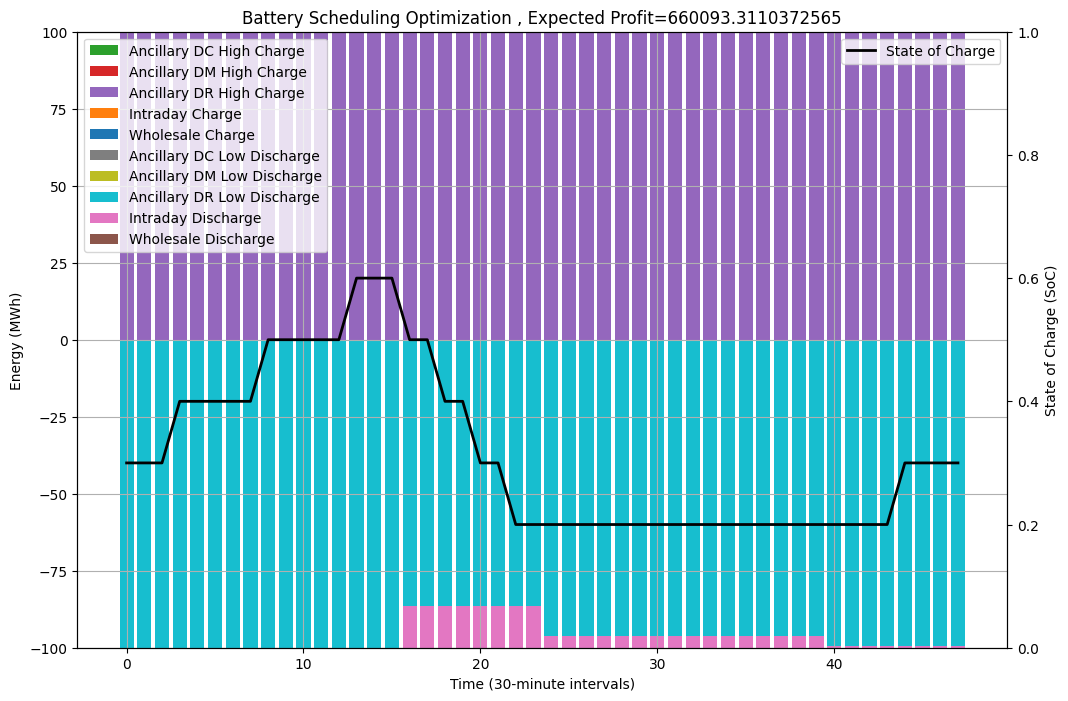

1 RangeSet Declarations
    t : Dimen=1, Size=48, Bounds=(0, 47)
        Key  : Finite : Members
        None :   True :  [0:47]

11 Var Declarations
    ancillary_dc_high_charge : Size=48, Index=t
        Key : Lower : Value : Upper : Fixed : Stale : Domain
          0 :     0 :   0.0 :   100 : False : False : NonNegativeReals
          1 :     0 :   0.0 :   100 : False : False : NonNegativeReals
          2 :     0 :   0.0 :   100 : False : False : NonNegativeReals
          3 :     0 :   0.0 :   100 : False : False : NonNegativeReals
          4 :     0 :   0.0 :   100 : False : False : NonNegativeReals
          5 :     0 :   0.0 :   100 : False : False : NonNegativeReals
          6 :     0 :   0.0 :   100 : False : False : NonNegativeReals
          7 :     0 :   0.0 :   100 : False : False : NonNegativeReals
          8 :     0 :   0.0 :   100 : False : False : NonNegativeReals
          9 :     0 :   0.0 :   100 : False : False : NonNegativeReals
         10 :     0 :   0.0 :  

660093.3110372565

In [3]:
# Extract the results
wholesale_charge_schedule = [pyo.value(model.wholesale_charge[t]) for t in model.t]
intraday_charge_schedule = [pyo.value(model.intraday_charge[t]) for t in model.t]
ancillary_dc_high_charge_schedule = [pyo.value(model.ancillary_dc_high_charge[t]) for t in model.t]
ancillary_dm_high_charge_schedule = [pyo.value(model.ancillary_dm_high_charge[t]) for t in model.t]
ancillary_dr_high_charge_schedule = [pyo.value(model.ancillary_dr_high_charge[t]) for t in model.t]

wholesale_discharge_schedule = [pyo.value(model.wholesale_discharge[t]) for t in model.t]
intraday_discharge_schedule = [pyo.value(model.intraday_discharge[t]) for t in model.t]
ancillary_dc_low_discharge_schedule = [pyo.value(model.ancillary_dc_low_discharge[t]) for t in model.t]
ancillary_dm_low_discharge_schedule = [pyo.value(model.ancillary_dm_low_discharge[t]) for t in model.t]
ancillary_dr_low_discharge_schedule = [pyo.value(model.ancillary_dr_low_discharge[t]) for t in model.t]

soc_schedule = [pyo.value(model.soc[t]) for t in model.t]

# Create the stacked bar plot
fig, ax1 = plt.subplots(figsize=(12, 8))

# Define colors for each service
charge_colors = {
    'wholesale': 'tab:blue',
    'intraday': 'tab:orange',
    'ancillary_dc': 'tab:green',
    'ancillary_dm': 'tab:red',
    'ancillary_dr': 'tab:purple'
}

discharge_colors = {
    'wholesale': 'tab:brown',
    'intraday': 'tab:pink',
    'ancillary_dc': 'tab:gray',
    'ancillary_dm': 'tab:olive',
    'ancillary_dr': 'tab:cyan'
}

# Plot the charge schedules as positive bars
ax1.bar(model.t, ancillary_dc_high_charge_schedule, label='Ancillary DC High Charge', color=charge_colors['ancillary_dc'])
ax1.bar(model.t, ancillary_dm_high_charge_schedule, bottom=np.array(ancillary_dc_high_charge_schedule), label='Ancillary DM High Charge', color=charge_colors['ancillary_dm'])
ax1.bar(model.t, ancillary_dr_high_charge_schedule, bottom=np.array(ancillary_dc_high_charge_schedule) + np.array(ancillary_dm_high_charge_schedule), label='Ancillary DR High Charge', color=charge_colors['ancillary_dr'])
ax1.bar(model.t, intraday_charge_schedule, bottom=np.array(ancillary_dc_high_charge_schedule) + np.array(ancillary_dm_high_charge_schedule) + np.array(ancillary_dr_high_charge_schedule), label='Intraday Charge', color=charge_colors['intraday'])
ax1.bar(model.t, wholesale_charge_schedule, bottom=np.array(ancillary_dc_high_charge_schedule) + np.array(ancillary_dm_high_charge_schedule) + np.array(ancillary_dr_high_charge_schedule) + np.array(intraday_charge_schedule), label='Wholesale Charge', color=charge_colors['wholesale'])

# Plot the discharge schedules as negative bars
ax1.bar(model.t, -np.array(ancillary_dc_low_discharge_schedule), label='Ancillary DC Low Discharge', color=discharge_colors['ancillary_dc'])
ax1.bar(model.t, -np.array(ancillary_dm_low_discharge_schedule), bottom=-np.array(ancillary_dc_low_discharge_schedule), label='Ancillary DM Low Discharge', color=discharge_colors['ancillary_dm'])
ax1.bar(model.t, -np.array(ancillary_dr_low_discharge_schedule), bottom=-np.array(ancillary_dc_low_discharge_schedule) - np.array(ancillary_dm_low_discharge_schedule), label='Ancillary DR Low Discharge', color=discharge_colors['ancillary_dr'])
ax1.bar(model.t, -np.array(intraday_discharge_schedule), bottom=-np.array(ancillary_dc_low_discharge_schedule) - np.array(ancillary_dm_low_discharge_schedule) - np.array(ancillary_dr_low_discharge_schedule), label='Intraday Discharge', color=discharge_colors['intraday'])
ax1.bar(model.t, -np.array(wholesale_discharge_schedule), bottom=-np.array(ancillary_dc_low_discharge_schedule) - np.array(ancillary_dm_low_discharge_schedule) - np.array(ancillary_dr_low_discharge_schedule) - np.array(intraday_discharge_schedule), label='Wholesale Discharge', color=discharge_colors['wholesale'])

# Overlay the state of charge (SoC) plot
ax2 = ax1.twinx()
ax2.plot(model.t, soc_schedule, label='State of Charge', color='black', linewidth=2)
ax2.set_ylim(0, 1)
ax2.set_ylabel('State of Charge (SoC)')

# Set labels and title
ax1.set_xlabel('Time (30-minute intervals)')
ax1.set_ylabel('Energy (MWh)')
ax1.set_title(f'Battery Scheduling Optimization , Expected Profit={model.objective()}')

# Add legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Show grid
ax1.grid(True)

# Show the plot
plt.show()
model.pprint()
model.objective()

### Constants
- $\eta_{ch} = 0.95$ (Charging efficiency)
- $\eta_{dis} = 0.95$ (Discharging efficiency)
- $\Delta t = 0.5$ (Time interval in hours)
- $C = 100$ (Battery capacity in MWh)
- $P_{max} = 100$ (Maximum power in MW)
- $SOC_{initial} = 0.3$ (Initial state of charge)
- $SOC_{final} = 0.3$ (Final state of charge)
- $SOC_H = 0.95$ (Upper SOC limit)
- $SOC_L = 0.05$ (Lower SOC limit)

### Decision Variables
- $P_{wholesale\_charge}(t)$: Wholesale market charge at time $t$
- $P_{intraday\_charge}(t)$: Intraday market charge at time $t$
- $P_{ancillary\_dc\_high\_charge}(t)$: Ancillary service DC high charge at time $t$
- $P_{ancillary\_dm\_high\_charge}(t)$: Ancillary service DM high charge at time $t$
- $P_{ancillary\_dr\_high\_charge}(t)$: Ancillary service DR high charge at time $t$
- $P_{wholesale\_discharge}(t)$: Wholesale market discharge at time $t$
- $P_{intraday\_discharge}(t)$: Intraday market discharge at time $t$
- $P_{ancillary\_dc\_low\_discharge}(t)$: Ancillary service DC low discharge at time $t$
- $P_{ancillary\_dm\_low\_discharge}(t)$: Ancillary service DM low discharge at time $t$
- $P_{ancillary\_dr\_low\_discharge}(t)$: Ancillary service DR low discharge at time $t$
- $SOC(t)$: State of charge at time $t$

### Initial and Final SoC Constraints
- Initial SoC: $SOC(0) = SOC_{initial}$
- Final SoC: $SOC(T) = SOC_{final}$

### SoC Constraint
For $t > 0$:
$$
SOC(t) = SOC(t-1) + \frac{\eta_{ch} \cdot P_{charging}(t) \cdot \Delta t}{C} - \frac{P_{discharging}(t) \cdot \Delta t}{\eta_{dis} \cdot C}
$$
where:
$$
P_{charging}(t) = P_{wholesale\_charge}(t) + P_{intraday\_charge}(t) + all\_ancillary\_utilization['DCH'][0][1][t] \cdot P_{ancillary\_dc\_high\_charge}(t) + all\_ancillary\_utilization['DMH'][0][1][t] \cdot P_{ancillary\_dm\_high\_charge}(t) + all\_ancillary\_utilization['DRH'][0][1][t] \cdot P_{ancillary\_dr\_high\_charge}(t)
$$
$$
P_{discharging}(t) = P_{wholesale\_discharge}(t) + P_{intraday\_discharge}(t) + all\_ancillary\_utilization['DCL'][0][1][t] \cdot P_{ancillary\_dc\_low\_discharge}(t) + all\_ancillary\_utilization['DML'][0][1][t] \cdot P_{ancillary\_dm\_low\_discharge}(t) + all\_ancillary\_utilization['DRL'][0][1][t] \cdot P_{ancillary\_dr\_low\_discharge}(t)
$$

### Wholesale Booking Constraints
For even $t$:
$$
P_{wholesale\_charge}(t) = P_{wholesale\_charge}(t+1)
$$
$$
P_{wholesale\_discharge}(t) = P_{wholesale\_discharge}(t+1)
$$

### Wholesale Charge and Discharge Constraint
$$
P_{wholesale\_charge}(t) + P_{wholesale\_discharge}(t) \leq P_{max}
$$

### Intraday Charge and Discharge Constraint
$$
P_{intraday\_charge}(t) + P_{intraday\_discharge}(t) \leq P_{max}
$$

### Ancillary Service Booking Constraints

For each ancillary service, the constraints ensure that the charge or discharge remains the same for every 8th time step.

#### DC High Booking Constraint
For even $t$:
$$
P_{ancillary\_dc\_high\_charge}(t) = P_{ancillary\_dc\_high\_charge}(t + i)
$$

#### DC Low Booking Constraint
For even $t$:
$$
P_{ancillary\_dc\_low\_discharge}(t) = P_{ancillary\_dc\_low\_discharge}(t + i)
$$

#### DM High Booking Constraint
For even $t$:
$$
P_{ancillary\_dm\_high\_charge}(t) = P_{ancillary\_dm\_high\_charge}(t + i)
$$

#### DM Low Booking Constraint
For even $t$:
$$
P_{ancillary\_dm\_low\_discharge}(t) = P_{ancillary\_dm\_low\_discharge}(t + i)
$$

#### DR High Booking Constraint
For even $t$:
$$
P_{ancillary\_dr\_high\_charge}(t) = P_{ancillary\_dr\_high\_charge}(t + i)
$$

#### DR Low Booking Constraint
For even $t$:
$$
P_{ancillary\_dr\_low\_discharge}(t) = P_{ancillary\_dr\_low\_discharge}(t + i)
$$

### Ancillary Service Support Constraints

#### DC High Support Constraint
$$
SOC_H - SOC(t) \geq \frac{interval \cdot P_{ancillary\_dc\_high\_charge}(t) \cdot \frac{15}{60}}{C}
$$

#### DM High Support Constraint
$$
SOC_H - SOC(t) \geq \frac{interval \cdot P_{ancillary\_dm\_high\_charge}(t) \cdot \frac{30}{60}}{C}
$$

#### DR High Support Constraint
$$
SOC_H - SOC(t) \geq \frac{interval \cdot P_{ancillary\_dr\_high\_charge}(t) \cdot \frac{60}{60}}{C}
$$

#### DC Low Support Constraint
$$
SOC(t) - SOC_L \geq \frac{interval \cdot P_{ancillary\_dc\_low\_discharge}(t) \cdot \frac{15}{60}}{C}
$$

#### DM Low Support Constraint
$$
SOC(t) - SOC_L \geq \frac{interval \cdot P_{ancillary\_dm\_low\_discharge}(t) \cdot \frac{15}{60}}{C}
$$

#### DR Low Support Constraint
$$
SOC(t) - SOC_L \geq \frac{interval \cdot P_{ancillary\_dr\_low\_discharge}(t) \cdot \frac{15}{60}}{C}
$$

### Headroom Constraint
$$
P_{wholesale\_charge}(t) + P_{intraday\_charge}(t) + P_{ancillary\_dc\_high\_charge}(t) + P_{ancillary\_dm\_high\_charge}(t) + P_{ancillary\_dr\_high\_charge}(t) \leq P_{max}
$$

### Footroom Constraint
$$
P_{wholesale\_discharge}(t) + P_{intraday\_discharge}(t) + P_{ancillary\_dc\_low\_discharge}(t) + P_{ancillary\_dm\_low\_discharge}(t) + P_{ancillary\_dr\_low\_discharge}(t) \leq P_{max}
$$

### Objective Function


$$
\sum_{t} \left( all\_wholesale\_price\_values[t] \cdot P_{wholesale\_charge}(t) - all\_wholesale\_price\_values[t] \cdot P_{wholesale\_discharge}(t) + all\_intraday\_price\_values[t] \cdot P_{intraday\_charge}(t) - all\_intraday\_price\_values[t] \cdot P_{intraday\_discharge}(t) + all\_ancillary\_dc\_price\_values[t] \cdot P_{ancillary\_dc\_high\_charge}(t) + all\_ancillary\_dc\_price\_values[t] \cdot P_{ancillary\_dc\_low\_discharge}(t) + all\_ancillary\_dm\_price\_values[t] \cdot P_{ancillary\_dm\_high\_charge}(t) + all\_ancillary\_dm\_price\_values[t] \cdot P_{ancillary\_dm\_low\_discharge}(t) + all\_ancillary\_dr\_price\_values[t] \cdot P_{ancillary\_dr\_high\_charge}(t) + all\_ancillary\_dr\_price\_values[t] \cdot P_{ancillary\_dr\_low\_discharge}(t) \right)
$$



# Scenarios Generation


In [10]:
import pyomo.environ as pyo

# Define constants
eta_ch = 0.95  # Charging efficiency
eta_dis = 0.95  # Discharging efficiency
interval = 0.5  # Time interval in hours (30 minutes)
C = 100  # Battery capacity in MWh
P_max = 100  # Maximum power in MW
initial_soc = 0.3  # Initial state of charge
final_soc = 0.3  # Final state of charge
SOC_H = 0.95 # Upper SOC limit
SOC_L = 0.05  # Lower SOC limit

# Define the Pyomo model
model = pyo.ConcreteModel()

# Define the time index
num_days = 1
num_samples_per_day = 48
model.t = pyo.RangeSet(0, num_days * num_samples_per_day - 1)

# Define scenarios
scenarios = ['scenario1', 'scenario2', 'scenario3']
probabilities = {'scenario1': 0.15, 'scenario2': 0.7, 'scenario3': 0.15}

# Define scenario-specific prices
all_wholesale_price_values_scenarios = {
    'scenario1': 1.5 * all_wholesale_price_values,
    'scenario2': 1.0 * all_wholesale_price_values,
    'scenario3': 0.5 * all_wholesale_price_values,
}

all_intraday_price_values_scenarios = {
    'scenario1': 1.2 * all_intraday_price_values,
    'scenario2': 1.0 * all_intraday_price_values,
    'scenario3': 0.8 * all_intraday_price_values,
}

all_ancillary_dc_price_values_scenarios = {
    'scenario1': 1.1 * all_ancillary_dc_price_values,
    'scenario2': 1.0 * all_ancillary_dc_price_values,
    'scenario3': 0.9 * all_ancillary_dc_price_values,
}

all_ancillary_dm_price_values_scenarios = {
    'scenario1': 1.05 * all_ancillary_dm_price_values,
    'scenario2': 1.0 * all_ancillary_dm_price_values,
    'scenario3': 0.95 * all_ancillary_dm_price_values,
}

all_ancillary_dr_price_values_scenarios = {
    'scenario1': 1.05 * all_ancillary_dr_price_values,
    'scenario2': 1.0 * all_ancillary_dr_price_values,
    'scenario3': 0.95 * all_ancillary_dr_price_values,
}


# Define decision variables for each type of market and ancillary service
model.wholesale_charge = pyo.Var(model.t, scenarios, within=pyo.NonNegativeReals, bounds=(0, P_max))
model.intraday_charge = pyo.Var(model.t, scenarios, within=pyo.NonNegativeReals, bounds=(0, P_max))
model.ancillary_dc_high_charge = pyo.Var(model.t, scenarios, within=pyo.NonNegativeReals, bounds=(0, P_max))
model.ancillary_dm_high_charge = pyo.Var(model.t, scenarios, within=pyo.NonNegativeReals, bounds=(0, P_max))
model.ancillary_dr_high_charge = pyo.Var(model.t, scenarios, within=pyo.NonNegativeReals, bounds=(0, P_max))

model.wholesale_discharge = pyo.Var(model.t, scenarios, within=pyo.NonNegativeReals, bounds=(0, P_max))
model.intraday_discharge = pyo.Var(model.t, scenarios, within=pyo.NonNegativeReals, bounds=(0, P_max))
model.ancillary_dc_low_discharge = pyo.Var(model.t, scenarios, within=pyo.NonNegativeReals, bounds=(0, P_max))
model.ancillary_dm_low_discharge = pyo.Var(model.t, scenarios, within=pyo.NonNegativeReals, bounds=(0, P_max))
model.ancillary_dr_low_discharge = pyo.Var(model.t, scenarios, within=pyo.NonNegativeReals, bounds=(0, P_max))

# Define the state of charge (SoC) variable
model.soc = pyo.Var(model.t, scenarios, within=pyo.NonNegativeReals, bounds=(SOC_L, SOC_H))

# Define initial and final SOC constraints
def initial_soc_constraint(model, scenario):
    return model.soc[0, scenario] == initial_soc
model.initial_soc_constraint = pyo.Constraint(scenarios, rule=initial_soc_constraint)

def final_soc_constraint(model, scenario):
    return model.soc[num_days * num_samples_per_day - 1, scenario] == final_soc
model.final_soc_constraint = pyo.Constraint(scenarios, rule=final_soc_constraint)

# Define SOC dynamics constraint
def soc_constraint(model, t, scenario):
    if t == 0:
        return pyo.Constraint.Skip  # Initial SoC is handled by initial_soc_constraint
    P_charging = (model.wholesale_charge[t, scenario] + model.intraday_charge[t, scenario] + 
                  all_ancillary_utilization['DCH'][0][1][t] * model.ancillary_dc_high_charge[t, scenario] + 
                  all_ancillary_utilization['DMH'][0][1][t] * model.ancillary_dm_high_charge[t, scenario] + 
                  all_ancillary_utilization['DRH'][0][1][t] * model.ancillary_dr_high_charge[t, scenario])
    P_discharging = (model.wholesale_discharge[t, scenario] + model.intraday_discharge[t, scenario] + 
                     all_ancillary_utilization['DCL'][0][1][t] * model.ancillary_dc_low_discharge[t, scenario] + 
                     all_ancillary_utilization['DML'][0][1][t] * model.ancillary_dm_low_discharge[t, scenario] + 
                     all_ancillary_utilization['DRL'][0][1][t] * model.ancillary_dr_low_discharge[t, scenario])
    return model.soc[t, scenario] == model.soc[t-1, scenario] + (eta_ch * P_charging * interval / C) - (P_discharging * interval / (eta_dis * C))
model.soc_constraint = pyo.Constraint(model.t, scenarios, rule=soc_constraint)

# Define the wholesale booking constraint
def wholesale_charging_booking_constraint(model, t, scenario):
    if t % 2 == 0 and t < num_days * num_samples_per_day - 1:
        return model.wholesale_charge[t, scenario] == model.wholesale_charge[t+1, scenario]
    return pyo.Constraint.Skip
model.wholesale_charging_booking_constraint = pyo.Constraint(model.t, scenarios, rule=wholesale_charging_booking_constraint)

def wholesale_discharge_booking_constraint(model, t, scenario):
    if t % 2 == 0 and t < num_days * num_samples_per_day - 1:
        return model.wholesale_discharge[t, scenario] == model.wholesale_discharge[t+1, scenario]
    return pyo.Constraint.Skip
model.wholesale_discharge_booking_constraint = pyo.Constraint(model.t, scenarios, rule=wholesale_discharge_booking_constraint)

# Define the constraint for wholesale charge and discharge
def wholesale_total_constraint(model, t, scenario):
    return model.wholesale_charge[t, scenario] + model.wholesale_discharge[t, scenario] <= P_max
model.wholesale_total_constraint = pyo.Constraint(model.t, scenarios, rule=wholesale_total_constraint)

# Define the constraint for intraday charge and discharge
def intraday_total_constraint(model, t, scenario):
    return model.intraday_charge[t, scenario] + model.intraday_discharge[t, scenario] <= P_max
model.intraday_total_constraint = pyo.Constraint(model.t, scenarios, rule=intraday_total_constraint)

# Define ancillary service booking constraints
def create_ancillary_dc_high_booking_constraint(model, t, scenario, offset):
    if t % 8 == 0 and t < num_days * num_samples_per_day - 7:
        return model.ancillary_dc_high_charge[t, scenario] == model.ancillary_dc_high_charge[t + offset, scenario]
    return pyo.Constraint.Skip

for i in range(8):
    setattr(model, f'ancillary_dc_high_booking_constraint_{i}', pyo.Constraint(model.t, scenarios, rule=lambda model, t, scenario, i=i: create_ancillary_dc_high_booking_constraint(model, t, scenario, i)))

def create_ancillary_dc_low_booking_constraint(model, t, scenario, offset):
    if t % 8 == 0 and t < num_days * num_samples_per_day - 7:
        return model.ancillary_dc_low_discharge[t, scenario] == model.ancillary_dc_low_discharge[t + offset, scenario]
    return pyo.Constraint.Skip

for i in range(8):
    setattr(model, f'ancillary_dc_low_booking_constraint_{i}', pyo.Constraint(model.t, scenarios, rule=lambda model, t, scenario, i=i: create_ancillary_dc_low_booking_constraint(model, t, scenario, i)))


def create_ancillary_dm_high_booking_constraint(model, t, scenario, offset):
    if t % 8 == 0 and t < num_days * num_samples_per_day - 7:
        return model.ancillary_dm_high_charge[t, scenario] == model.ancillary_dm_high_charge[t + offset, scenario]
    return pyo.Constraint.Skip

for i in range(8):
    setattr(model, f'ancillary_dm_high_booking_constraint_{i}', pyo.Constraint(model.t, scenarios, rule=lambda model, t, scenario, i=i: create_ancillary_dm_high_booking_constraint(model, t, scenario, i)))

def create_ancillary_dm_low_booking_constraint(model, t, scenario, offset):
    if t % 8 == 0 and t < num_days * num_samples_per_day - 7:
        return model.ancillary_dm_low_discharge[t, scenario] == model.ancillary_dm_low_discharge[t + offset, scenario]
    return pyo.Constraint.Skip

for i in range(8):
    setattr(model, f'ancillary_dm_low_booking_constraint_{i}', pyo.Constraint(model.t, scenarios, rule=lambda model, t, scenario, i=i: create_ancillary_dm_low_booking_constraint(model, t, scenario, i)))

def create_ancillary_dr_high_booking_constraint(model, t, scenario, offset):
    if t % 8 == 0 and t < num_days * num_samples_per_day - 7:
        return model.ancillary_dr_high_charge[t, scenario] == model.ancillary_dr_high_charge[t + offset, scenario]
    return pyo.Constraint.Skip

for i in range(8):
    setattr(model, f'ancillary_dr_high_booking_constraint_{i}', pyo.Constraint(model.t, scenarios, rule=lambda model, t, scenario, i=i: create_ancillary_dr_high_booking_constraint(model, t, scenario, i)))

def create_ancillary_dr_low_booking_constraint(model, t, scenario, offset):
    if t % 8 == 0 and t < num_days * num_samples_per_day - 7:
        return model.ancillary_dr_low_discharge[t, scenario] == model.ancillary_dr_low_discharge[t + offset, scenario]
    return pyo.Constraint.Skip

for i in range(8):
    setattr(model, f'ancillary_dr_low_booking_constraint_{i}', pyo.Constraint(model.t, scenarios, rule=lambda model, t, scenario, i=i: create_ancillary_dr_low_booking_constraint(model, t, scenario, i)))


# Define the ancillary service support constraints
def dch_support_constraint(model, t, scenario):
    return SOC_H - model.soc[t, scenario] >= interval*(model.ancillary_dc_high_charge[t, scenario] * (15/60)) / C
model.dch_support_constraint = pyo.Constraint(model.t, scenarios, rule=dch_support_constraint)

def dmh_support_constraint(model, t, scenario):
    return SOC_H - model.soc[t, scenario] >= interval*(model.ancillary_dm_high_charge[t, scenario] * (30/60)) / C
model.dmh_support_constraint = pyo.Constraint(model.t, scenarios, rule=dmh_support_constraint)

def drh_support_constraint(model, t, scenario):
    return SOC_H - model.soc[t, scenario] >= interval*(model.ancillary_dr_high_charge[t, scenario] * (60/60)) / C
model.dmh_support_constraint = pyo.Constraint(model.t, scenarios, rule=dmh_support_constraint)

def dcl_support_constraint(model, t, scenario):
    return model.soc[t, scenario]- SOC_L >= interval*(model.ancillary_dc_low_discharge[t, scenario] * (15/60)) / C
model.dcl_support_constraint = pyo.Constraint(model.t, scenarios, rule=dcl_support_constraint)

def dml_support_constraint(model, t, scenario):
    return model.soc[t, scenario]- SOC_L >= interval*(model.ancillary_dm_low_discharge[t, scenario] * (15/60)) / C
model.dml_support_constraint = pyo.Constraint(model.t, scenarios, rule=dml_support_constraint)

def drl_support_constraint(model, t, scenario):
    return model.soc[t, scenario]- SOC_L >= interval*(model.ancillary_dr_low_discharge[t, scenario] * (15/60)) / C
model.drl_support_constraint = pyo.Constraint(model.t, scenarios, rule=drl_support_constraint)

# Define the headroom constraint
def headroom_constraint(model, t, scenario):
    return model.wholesale_charge[t, scenario] + model.intraday_charge[t, scenario] + model.ancillary_dc_high_charge[t, scenario] + model.ancillary_dm_high_charge[t, scenario] + model.ancillary_dr_high_charge[t, scenario] <= P_max
model.headroom_constraint = pyo.Constraint(model.t, scenarios, rule=headroom_constraint)

# Define the footroom constraint
def footroom_constraint(model, t, scenario):
    return model.wholesale_discharge[t, scenario] + model.intraday_discharge[t, scenario] + model.ancillary_dc_low_discharge[t, scenario] + model.ancillary_dm_low_discharge[t, scenario] + model.ancillary_dr_low_discharge[t, scenario] <= P_max
model.footroom_constraint = pyo.Constraint(model.t, scenarios, rule=footroom_constraint)

# Define the objective function
def objective_function(model):
    return sum(
        probabilities[scenario] * sum(
            all_wholesale_price_values_scenarios[scenario][t] * model.wholesale_charge[t, scenario] - all_wholesale_price_values_scenarios[scenario][t] * model.wholesale_discharge[t, scenario]
            + all_intraday_price_values_scenarios[scenario][t] * model.intraday_charge[t, scenario] - all_intraday_price_values_scenarios[scenario][t] * model.intraday_discharge[t, scenario]
            + all_ancillary_dc_price_values_scenarios[scenario][t] * model.ancillary_dc_high_charge[t, scenario] + all_ancillary_dc_price_values_scenarios[scenario][t] * model.ancillary_dc_low_discharge[t, scenario]
            + all_ancillary_dm_price_values_scenarios[scenario][t] * model.ancillary_dm_high_charge[t, scenario] + all_ancillary_dm_price_values_scenarios[scenario][t] * model.ancillary_dm_low_discharge[t, scenario]
            + all_ancillary_dr_price_values_scenarios[scenario][t] * model.ancillary_dr_high_charge[t, scenario] + all_ancillary_dr_price_values_scenarios[scenario][t] * model.ancillary_dr_low_discharge[t, scenario]
            for t in model.t
        )
        for scenario in scenarios
    )
model.objective = pyo.Objective(rule=objective_function, sense=pyo.maximize)

# Solve the optimization problem
solver = pyo.SolverFactory('glpk')
solver.solve(model)
print(model.objective())
model.display()
# model.pprint()

# Round the results to one decimal place
for t in model.t:
    for scenario in scenarios:
        model.wholesale_charge[t, scenario].value = round(model.wholesale_charge[t, scenario].value, 1)
        model.intraday_charge[t, scenario].value = round(model.intraday_charge[t, scenario].value, 1)
        model.ancillary_dc_high_charge[t, scenario].value = round(model.ancillary_dc_high_charge[t, scenario].value, 1)
        model.ancillary_dm_high_charge[t, scenario].value = round(model.ancillary_dm_high_charge[t, scenario].value, 1)
        model.ancillary_dr_high_charge[t, scenario].value = round(model.ancillary_dr_high_charge[t, scenario].value, 1)
        model.wholesale_discharge[t, scenario].value = round(model.wholesale_discharge[t, scenario].value, 1)
        model.intraday_discharge[t, scenario].value = round(model.intraday_discharge[t, scenario].value, 1)
        model.ancillary_dc_low_discharge[t, scenario].value = round(model.ancillary_dc_low_discharge[t, scenario].value, 1)
        model.ancillary_dm_low_discharge[t, scenario].value = round(model.ancillary_dm_low_discharge[t, scenario].value, 1)
        model.ancillary_dr_low_discharge[t, scenario].value = round(model.ancillary_dr_low_discharge[t, scenario].value, 1)
        model.soc[t, scenario].value = round(model.soc[t, scenario].value, 1)


(type=<class 'pyomo.core.base.constraint.IndexedConstraint'>) on block unknown
with a new Component (type=<class
'pyomo.core.base.constraint.IndexedConstraint'>). This is usually indicative
of a modelling error. To avoid this warning, use block.del_component() and
block.add_component().
660516.3956571535
Model unknown

  Variables:
    wholesale_charge : Size=144, Index=t*{scenario1, scenario2, scenario3}
        Key               : Lower : Value                 : Upper : Fixed : Stale : Domain
         (0, 'scenario1') :     0 :                   0.0 :   100 : False : False : NonNegativeReals
         (0, 'scenario2') :     0 :                   0.0 :   100 : False : False : NonNegativeReals
         (0, 'scenario3') :     0 :                   0.0 :   100 : False : False : NonNegativeReals
         (1, 'scenario1') :     0 :                   0.0 :   100 : False : False : NonNegativeReals
         (1, 'scenario2') :     0 :                   0.0 :   100 : False : False : NonNegativeR

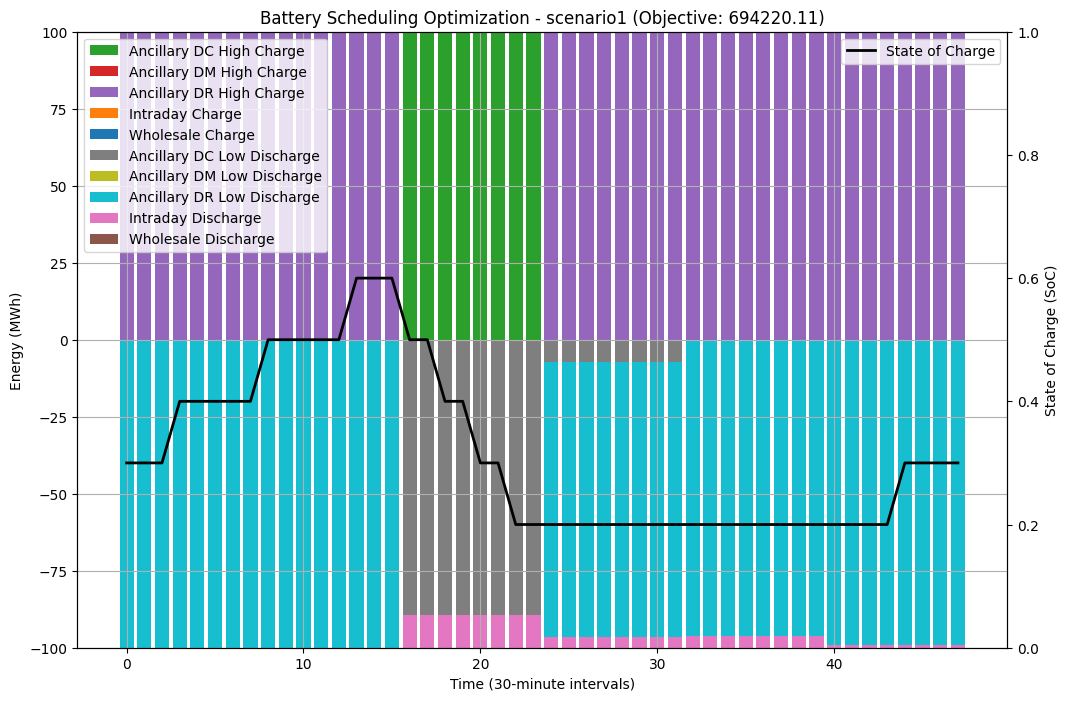

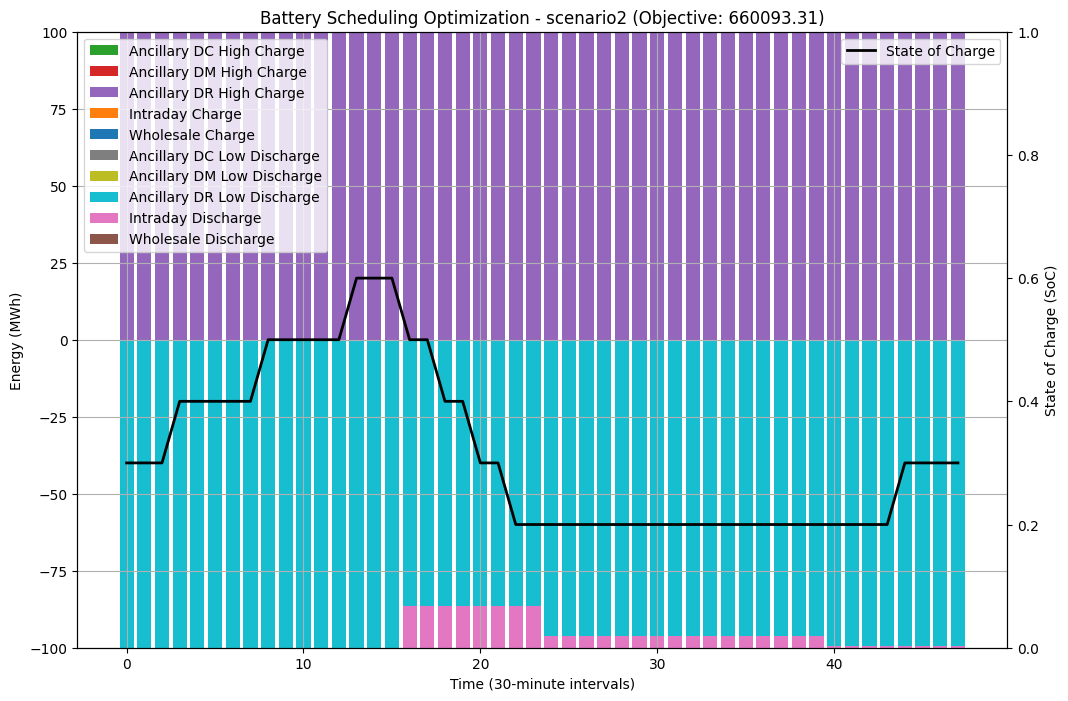

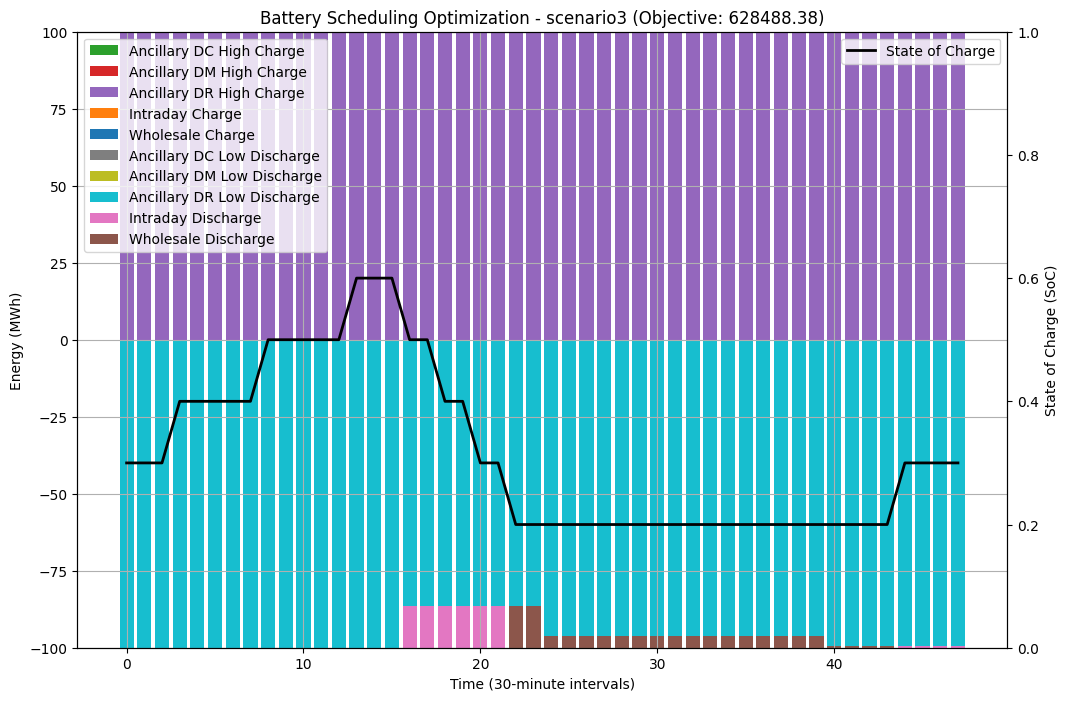

In [11]:
# Extract the results for each scenario
results = {}
for scenario in scenarios:
    results[scenario] = {
        'wholesale_charge': [pyo.value(model.wholesale_charge[t, scenario]) for t in model.t],
        'intraday_charge': [pyo.value(model.intraday_charge[t, scenario]) for t in model.t],
        'ancillary_dc_high_charge': [pyo.value(model.ancillary_dc_high_charge[t, scenario]) for t in model.t],
        'ancillary_dm_high_charge': [pyo.value(model.ancillary_dm_high_charge[t, scenario]) for t in model.t],
        'ancillary_dr_high_charge': [pyo.value(model.ancillary_dr_high_charge[t, scenario]) for t in model.t],
        'wholesale_discharge': [pyo.value(model.wholesale_discharge[t, scenario]) for t in model.t],
        'intraday_discharge': [pyo.value(model.intraday_discharge[t, scenario]) for t in model.t],
        'ancillary_dc_low_discharge': [pyo.value(model.ancillary_dc_low_discharge[t, scenario]) for t in model.t],
        'ancillary_dm_low_discharge': [pyo.value(model.ancillary_dm_low_discharge[t, scenario]) for t in model.t],
        'ancillary_dr_low_discharge': [pyo.value(model.ancillary_dr_low_discharge[t, scenario]) for t in model.t],
        'soc': [pyo.value(model.soc[t, scenario]) for t in model.t]
    }

# Calculate the objective value for each scenario
objective_values = {}
for scenario in scenarios:
    objective_values[scenario] = sum(
        all_wholesale_price_values_scenarios[scenario][t] * results[scenario]['wholesale_charge'][t] - all_wholesale_price_values_scenarios[scenario][t] * results[scenario]['wholesale_discharge'][t]
        + all_intraday_price_values_scenarios[scenario][t] * results[scenario]['intraday_charge'][t] - all_intraday_price_values_scenarios[scenario][t] * results[scenario]['intraday_discharge'][t]
        + all_ancillary_dc_price_values_scenarios[scenario][t] * results[scenario]['ancillary_dc_high_charge'][t] + all_ancillary_dc_price_values_scenarios[scenario][t] * results[scenario]['ancillary_dc_low_discharge'][t]
        + all_ancillary_dm_price_values_scenarios[scenario][t] * results[scenario]['ancillary_dm_high_charge'][t] + all_ancillary_dm_price_values_scenarios[scenario][t] * results[scenario]['ancillary_dm_low_discharge'][t]
        + all_ancillary_dr_price_values_scenarios[scenario][t] * results[scenario]['ancillary_dr_high_charge'][t] + all_ancillary_dr_price_values_scenarios[scenario][t] * results[scenario]['ancillary_dr_low_discharge'][t]
        for t in model.t
    )    

# Plot the results for each scenario
for scenario in scenarios:
    fig, ax1 = plt.subplots(figsize=(12, 8))

    # Define colors for each service
    charge_colors = {
        'wholesale': 'tab:blue',
        'intraday': 'tab:orange',
        'ancillary_dc': 'tab:green',
        'ancillary_dm': 'tab:red',
        'ancillary_dr': 'tab:purple'
    }

    discharge_colors = {
        'wholesale': 'tab:brown',
        'intraday': 'tab:pink',
        'ancillary_dc': 'tab:gray',
        'ancillary_dm': 'tab:olive',
        'ancillary_dr': 'tab:cyan'
    }

    # Plot the charge schedules as positive bars
    ax1.bar(model.t, results[scenario]['ancillary_dc_high_charge'], label='Ancillary DC High Charge', color=charge_colors['ancillary_dc'])
    ax1.bar(model.t, results[scenario]['ancillary_dm_high_charge'], bottom=np.array(results[scenario]['ancillary_dc_high_charge']), label='Ancillary DM High Charge', color=charge_colors['ancillary_dm'])
    ax1.bar(model.t, results[scenario]['ancillary_dr_high_charge'], bottom=np.array(results[scenario]['ancillary_dc_high_charge']) + np.array(results[scenario]['ancillary_dm_high_charge']), label='Ancillary DR High Charge', color=charge_colors['ancillary_dr'])
    ax1.bar(model.t, results[scenario]['intraday_charge'], bottom=np.array(results[scenario]['ancillary_dc_high_charge']) + np.array(results[scenario]['ancillary_dm_high_charge']) + np.array(results[scenario]['ancillary_dr_high_charge']), label='Intraday Charge', color=charge_colors['intraday'])
    ax1.bar(model.t, results[scenario]['wholesale_charge'], bottom=np.array(results[scenario]['ancillary_dc_high_charge']) + np.array(results[scenario]['ancillary_dm_high_charge']) + np.array(results[scenario]['ancillary_dr_high_charge']) + np.array(results[scenario]['intraday_charge']), label='Wholesale Charge', color=charge_colors['wholesale'])

    # Plot the discharge schedules as negative bars
    ax1.bar(model.t, -np.array(results[scenario]['ancillary_dc_low_discharge']), label='Ancillary DC Low Discharge', color=discharge_colors['ancillary_dc'])
    ax1.bar(model.t, -np.array(results[scenario]['ancillary_dm_low_discharge']), bottom=-np.array(results[scenario]['ancillary_dc_low_discharge']), label='Ancillary DM Low Discharge', color=discharge_colors['ancillary_dm'])
    ax1.bar(model.t, -np.array(results[scenario]['ancillary_dr_low_discharge']), bottom=-np.array(results[scenario]['ancillary_dc_low_discharge']) - np.array(results[scenario]['ancillary_dm_low_discharge']), label='Ancillary DR Low Discharge', color=discharge_colors['ancillary_dr'])
    ax1.bar(model.t, -np.array(results[scenario]['intraday_discharge']), bottom=-np.array(results[scenario]['ancillary_dc_low_discharge']) - np.array(results[scenario]['ancillary_dm_low_discharge']) - np.array(results[scenario]['ancillary_dr_low_discharge']), label='Intraday Discharge', color=discharge_colors['intraday'])
    ax1.bar(model.t, -np.array(results[scenario]['wholesale_discharge']), bottom=-np.array(results[scenario]['ancillary_dc_low_discharge']) - np.array(results[scenario]['ancillary_dm_low_discharge']) - np.array(results[scenario]['ancillary_dr_low_discharge']) - np.array(results[scenario]['intraday_discharge']), label='Wholesale Discharge', color=discharge_colors['wholesale'])

    # Overlay the state of charge (SoC) plot
    ax2 = ax1.twinx()
    ax2.plot(model.t, results[scenario]['soc'], label='State of Charge', color='black', linewidth=2)
    ax2.set_ylim(0, 1)
    ax2.set_ylabel('State of Charge (SoC)')

    # Set labels and title
    ax1.set_xlabel('Time (30-minute intervals)')
    ax1.set_ylabel('Energy (MWh)')
    ax1.set_title(f'Battery Scheduling Optimization - {scenario} (Objective: {objective_values[scenario]:.2f})')

    # Add legends
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

    # Show grid
    ax1.grid(True)

    # Show the plot
    plt.show()


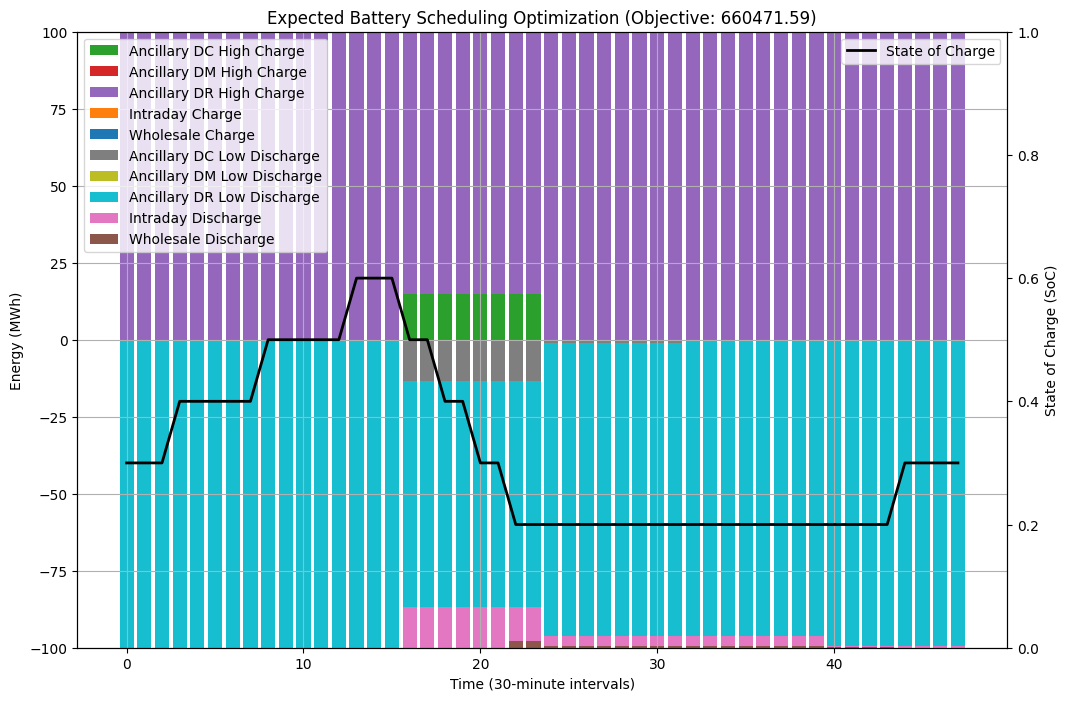

In [12]:
# TODO: SOC tracking is not exactly right
# Calculate the expected schedule by taking the weighted average of the schedules from each scenario
expected_schedule = {
    'wholesale_charge': np.zeros(num_samples_per_day),
    'intraday_charge': np.zeros(num_samples_per_day),
    'ancillary_dc_high_charge': np.zeros(num_samples_per_day),
    'ancillary_dm_high_charge': np.zeros(num_samples_per_day),
    'ancillary_dr_high_charge': np.zeros(num_samples_per_day),
    'wholesale_discharge': np.zeros(num_samples_per_day),
    'intraday_discharge': np.zeros(num_samples_per_day),
    'ancillary_dc_low_discharge': np.zeros(num_samples_per_day),
    'ancillary_dm_low_discharge': np.zeros(num_samples_per_day),
    'ancillary_dr_low_discharge': np.zeros(num_samples_per_day),
    'soc': np.zeros(num_samples_per_day)
}

for scenario in scenarios:
    for key in expected_schedule.keys():
        expected_schedule[key] += probabilities[scenario] * np.array(results[scenario][key])

# Calculate the expected objective value
expected_objective_value = sum(probabilities[scenario] * objective_values[scenario] for scenario in scenarios)


# Plot the expected schedule
fig, ax1 = plt.subplots(figsize=(12, 8))

# Define colors for each service
charge_colors = {
    'wholesale': 'tab:blue',
    'intraday': 'tab:orange',
    'ancillary_dc': 'tab:green',
    'ancillary_dm': 'tab:red',
    'ancillary_dr': 'tab:purple'
}

discharge_colors = {
    'wholesale': 'tab:brown',
    'intraday': 'tab:pink',
    'ancillary_dc': 'tab:gray',
    'ancillary_dm': 'tab:olive',
    'ancillary_dr': 'tab:cyan'
}

# Plot the charge schedules as positive bars
ax1.bar(model.t, expected_schedule['ancillary_dc_high_charge'], label='Ancillary DC High Charge', color=charge_colors['ancillary_dc'])
ax1.bar(model.t, expected_schedule['ancillary_dm_high_charge'], bottom=expected_schedule['ancillary_dc_high_charge'], label='Ancillary DM High Charge', color=charge_colors['ancillary_dm'])
ax1.bar(model.t, expected_schedule['ancillary_dr_high_charge'], bottom=expected_schedule['ancillary_dc_high_charge'] + expected_schedule['ancillary_dm_high_charge'], label='Ancillary DR High Charge', color=charge_colors['ancillary_dr'])
ax1.bar(model.t, expected_schedule['intraday_charge'], bottom=expected_schedule['ancillary_dc_high_charge'] + expected_schedule['ancillary_dm_high_charge'] + expected_schedule['ancillary_dr_high_charge'], label='Intraday Charge', color=charge_colors['intraday'])
ax1.bar(model.t, expected_schedule['wholesale_charge'], bottom=expected_schedule['ancillary_dc_high_charge'] + expected_schedule['ancillary_dm_high_charge'] + expected_schedule['ancillary_dr_high_charge'] + expected_schedule['intraday_charge'], label='Wholesale Charge', color=charge_colors['wholesale'])

# Plot the discharge schedules as negative bars
ax1.bar(model.t, -expected_schedule['ancillary_dc_low_discharge'], label='Ancillary DC Low Discharge', color=discharge_colors['ancillary_dc'])
ax1.bar(model.t, -expected_schedule['ancillary_dm_low_discharge'], bottom=-expected_schedule['ancillary_dc_low_discharge'], label='Ancillary DM Low Discharge', color=discharge_colors['ancillary_dm'])
ax1.bar(model.t, -expected_schedule['ancillary_dr_low_discharge'], bottom=-expected_schedule['ancillary_dc_low_discharge'] - expected_schedule['ancillary_dm_low_discharge'], label='Ancillary DR Low Discharge', color=discharge_colors['ancillary_dr'])
ax1.bar(model.t, -expected_schedule['intraday_discharge'], bottom=-expected_schedule['ancillary_dc_low_discharge'] - expected_schedule['ancillary_dm_low_discharge'] - expected_schedule['ancillary_dr_low_discharge'], label='Intraday Discharge', color=discharge_colors['intraday'])
ax1.bar(model.t, -expected_schedule['wholesale_discharge'], bottom=-expected_schedule['ancillary_dc_low_discharge'] - expected_schedule['ancillary_dm_low_discharge'] - expected_schedule['ancillary_dr_low_discharge'] - expected_schedule['intraday_discharge'], label='Wholesale Discharge', color=discharge_colors['wholesale'])

# Overlay the state of charge (SoC) plot
ax2 = ax1.twinx()
ax2.plot(model.t, expected_schedule['soc'], label='State of Charge', color='black', linewidth=2)
ax2.set_ylim(0, 1)
ax2.set_ylabel('State of Charge (SoC)')

# Set labels and title
ax1.set_xlabel('Time (30-minute intervals)')
ax1.set_ylabel('Energy (MWh)')
ax1.set_title(f'Expected Battery Scheduling Optimization (Objective: {expected_objective_value:.2f})')

# Add legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Show grid
ax1.grid(True)

# Show the plot
plt.show()